In [1]:

# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras
import h5py 

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt
from keras import regularizers


from sklearn.model_selection import GridSearchCV
from keras.wrappers.scikit_learn import KerasClassifier
from keras.optimizers import Adam

print(tf.__version__)

Using TensorFlow backend.


2.2.0-rc3


Google SVHN Dataset

In [0]:
from google.colab import drive
drive.mount('/content/drive')

In [3]:
h5f= h5py.File('/content/drive/My Drive/Colab Notebooks/SVHN_single_grey1.h5','r')
list(h5f.keys())

['X_test', 'X_train', 'X_val', 'y_test', 'y_train', 'y_val']

In [4]:
X_train=h5f['X_train'][:]
y_train =h5f['y_train'][:]

X_test=h5f['X_test'][:]
y_test =h5f['y_test'][:]

X_val=h5f['X_val'][:]
y_val =h5f['y_val'][:]
h5f.close()

print('Training set', X_train.shape, y_train.shape)
print('Validation set', X_val.shape, y_val.shape)
print('Test set', X_test.shape, y_test.shape)





Training set (42000, 32, 32) (42000,)
Validation set (60000, 32, 32) (60000,)
Test set (18000, 32, 32) (18000,)


Check unique Labels

In [5]:
print(np.unique(y_train))

[0 1 2 3 4 5 6 7 8 9]


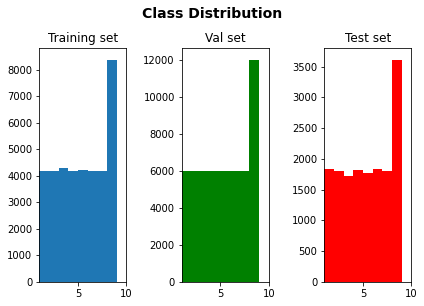

In [6]:
fig, (ax1, ax2,ax3) = plt.subplots(1, 3, sharex=True)

fig.suptitle('Class Distribution', fontsize=14, fontweight='bold', y=1.05)

ax1.hist(y_train, bins=9)
ax1.set_title("Training set")
ax1.set_xlim(1, 10)

ax2.hist(y_val, color='g', bins=9)
ax2.set_title("Val set")

ax3.hist(y_test, color='r', bins=9)
ax3.set_title("Test set")

fig.tight_layout()

The data set skewed towards 9 but otherwise looks like a balanced classification

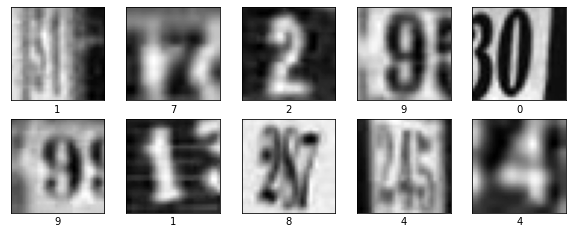

In [7]:
plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_test[i], cmap=plt.cm.binary)
    plt.xlabel(y_test[i])
plt.show()

In [0]:
X_train=X_train.reshape((42000, 32* 32))
X_train = X_train.astype('float32') / 255

X_test=X_test.reshape((18000, 32* 32))
X_test = X_test.astype('float32') / 255

X_val=X_val.reshape((60000, 32* 32))
X_val = X_val.astype('float32') / 255



In [0]:
from keras.utils import to_categorical
y_train = to_categorical(y_train)
y_test= to_categorical(y_test)
y_val= to_categorical(y_val)


In [0]:
model = keras.Sequential([
   # keras.layers.Flatten(input_shape=(32, 32,)),
    keras.layers.BatchNormalization(),
    #keras.layers.Dense(512, activation='relu'),
   # keras.layers.BatchNormalization(),
    #keras.layers.Dropout(0.1),
    #keras.layers.Dense(256, activation='relu'),
    #keras.layers.Dropout(0.3),

    #keras.layers.Dropout(0.3),
    #keras.layers.BatchNormalization(),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    
    #keras.layers.BatchNormalization(),
    #keras.layers.Dense(64, activation='relu'),
    #keras.layers.BatchNormalization(),
    #keras.layers.Dense(32, activation='relu'),
    #keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(10,activation='softmax')
])

In [0]:

#model.compile(optimizer='keras.optimizers.Adam()',
 #             loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  #            metrics=['accuracy'])

In [0]:
model.compile(optimizer='rmsprop',loss='categorical_crossentropy',metrics=['accuracy'])

In [23]:
history = model.fit(X_train, y_train, epochs=50,batch_size= 500,validation_data=(X_val,y_val)
          )

Epoch 1/50
84/84 [==============================] - 7s 83ms/step - loss: 1.8748 - accuracy: 0.3587 - val_loss: 1.7952 - val_accuracy: 0.4980
Epoch 2/50
84/84 [==============================] - 7s 79ms/step - loss: 1.1973 - accuracy: 0.6150 - val_loss: 1.3529 - val_accuracy: 0.6757
Epoch 3/50
84/84 [==============================] - 7s 79ms/step - loss: 0.9870 - accuracy: 0.6855 - val_loss: 1.0013 - val_accuracy: 0.7130
Epoch 4/50
84/84 [==============================] - 7s 79ms/step - loss: 0.8691 - accuracy: 0.7236 - val_loss: 0.8405 - val_accuracy: 0.7500
Epoch 5/50
84/84 [==============================] - 7s 79ms/step - loss: 0.7879 - accuracy: 0.7515 - val_loss: 0.7109 - val_accuracy: 0.7825
Epoch 6/50
84/84 [==============================] - 7s 79ms/step - loss: 0.7143 - accuracy: 0.7775 - val_loss: 0.7209 - val_accuracy: 0.7745
Epoch 7/50
84/84 [==============================] - 7s 79ms/step - loss: 0.6660 - accuracy: 0.7933 - val_loss: 0.5929 - val_accuracy: 0.8182
Epoch 8/50
84

In [24]:
test_loss, test_acc = model.evaluate(X_test,  y_test, verbose=2)

print('\nTest accuracy:', test_acc)

563/563 - 1s - loss: 0.8513 - accuracy: 0.8492

Test accuracy: 0.8491666913032532


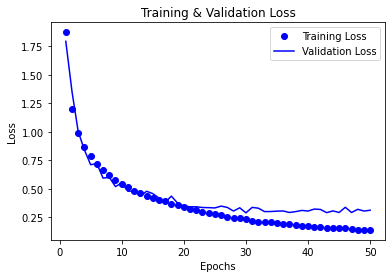

In [25]:
history_dict=history.history
history_dict.keys()
loss_values=history_dict['loss']
val_loss_values=history_dict['val_loss']
epochs= range(1,len(loss_values)+1)
plt.plot(epochs,loss_values,'bo',label='Training Loss')
plt.plot(epochs,val_loss_values,'b',label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

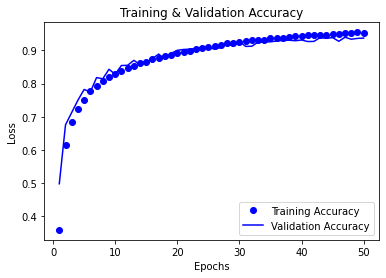

In [26]:
plt.clf()

acc=history_dict['accuracy']
val_acc=history_dict['val_accuracy']

plt.plot(epochs,acc,'bo',label='Training Accuracy')
plt.plot(epochs,val_acc,'b',label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()